In [1]:
import sys
import logging
from pathlib import Path

import numpy as np
import mlflow
import mlflow.pytorch
from sklearn.model_selection import train_test_split

sys.path.append(str(Path("..").resolve()))

from src.features import load_raw_data, split_features_target, build_preprocessor
from src.model import build_model
from src.train import train_model, get_device, set_seeds
from src.evaluate import (
    get_predictions,
    compute_metrics,
    compute_cost_analysis,
    plot_training_history,
    plot_roc_curve,
    plot_pr_curve,
    plot_confusion_matrix,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
)

SEED = 1312
FIGURES_DIR = Path("../docs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


In [2]:
df = load_raw_data(Path("../data/raw/telco_churn.csv"))
X, y = split_features_target(df)

preprocessor = build_preprocessor()
y_array = y.values

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y_array,
    test_size=0.2,
    random_state=SEED,
    stratify=y_array,
)

# fit apenas no treino !!
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)

print(f"Treino: {X_train.shape}")
print(f"Validação: {X_val.shape}")
print(f"Churn no treino: {y_train.mean():.1%}")
print(f"Churn na validação: {y_val.mean():.1%}")

Treino: (5608, 44)
Validação: (1402, 44)
Churn no treino: 26.5%
Churn na validação: 26.5%


In [3]:
DB_PATH = Path("../models/mlflow.db").resolve()
MLFLOW_TRACKING_URI = f"sqlite:///{DB_PATH}"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("churn-mlp")

print("MLflow configurado:", MLFLOW_TRACKING_URI)
print("Experimento: churn-mlp")

MLflow configurado: sqlite:///C:\Users\bruno\OneDrive\Estudos\Especialização\Postech_MLE\modulo_01\Projeto-Churn-TC01\models\mlflow.db
Experimento: churn-mlp


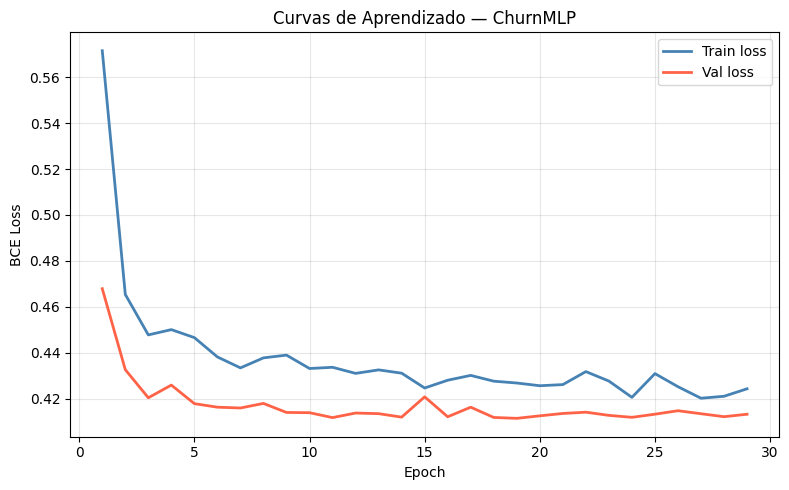

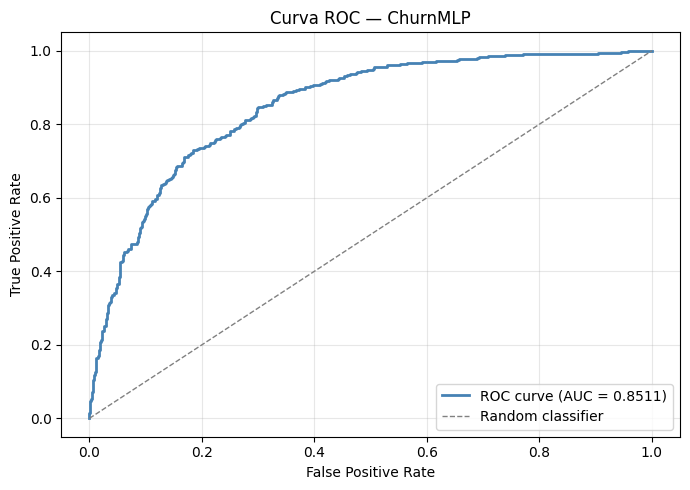

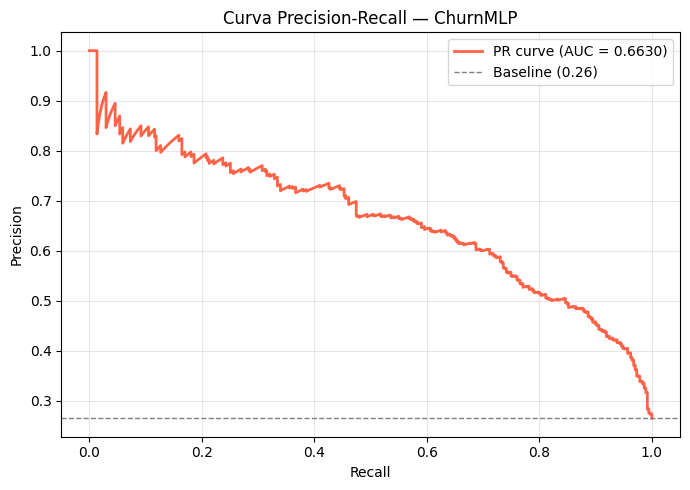

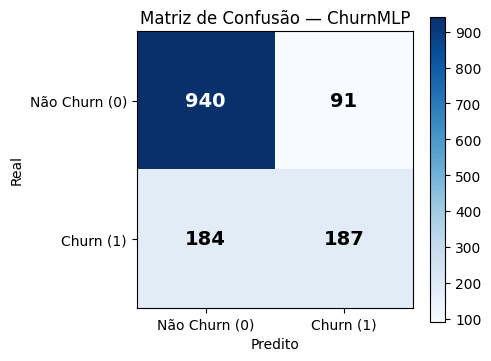

2026/04/26 22:47:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 22:47:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/26 22:47:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



ROC-AUC:  0.8511
PR-AUC:   0.6630
F1:       0.5763
Recall:   0.5040
Economia: R$88.950


In [4]:
# Hiperparâmetros do experimento
HIDDEN_DIMS   = [64, 32, 16]
DROPOUT_RATE  = 0.3
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
MAX_EPOCHS    = 100
PATIENCE      = 10

with mlflow.start_run(run_name="ChurnMLP_v1"):
    
    mlflow.log_params({
        "hidden_dims":   str(HIDDEN_DIMS),
        "dropout_rate":  DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "batch_size":    BATCH_SIZE,
        "max_epochs":    MAX_EPOCHS,
        "patience":      PATIENCE,
        "seed":          SEED,
        "input_dim":     X_train.shape[1],
        "n_train":       X_train.shape[0],
        "n_val":         X_val.shape[0],
    })

    model, history = train_model(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        input_dim=X_train.shape[1],
        hidden_dims=HIDDEN_DIMS,
        dropout_rate=DROPOUT_RATE,
        learning_rate=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
    )

    for epoch, (tl, vl) in enumerate(
        zip(history["train_loss"], history["val_loss"]), start=1
    ):
        mlflow.log_metrics({"train_loss": tl, "val_loss": vl}, step=epoch)

    device = get_device()
    y_proba, y_pred = get_predictions(model, X_val, device)
    metrics = compute_metrics(y_val, y_proba, y_pred)
    cost    = compute_cost_analysis(y_val, y_pred)

    mlflow.log_metrics({
        "roc_auc":   metrics["roc_auc"],
        "pr_auc":    metrics["pr_auc"],
        "f1":        metrics["f1"],
        "recall":    metrics["recall"],
        "precision": metrics["precision"],
        "savings":   cost["savings"],
    })

    plot_training_history(history, save_path=FIGURES_DIR / "training_history.png")
    plot_roc_curve(y_val, y_proba, save_path=FIGURES_DIR / "roc_curve.png")
    plot_pr_curve(y_val, y_proba,  save_path=FIGURES_DIR / "pr_curve.png")
    plot_confusion_matrix(y_val, y_pred, save_path=FIGURES_DIR / "confusion_matrix.png")

    mlflow.log_artifacts(str(FIGURES_DIR), artifact_path="figures")

    mlflow.pytorch.log_model(model, artifact_path="model")

    print(f"\nROC-AUC:  {metrics['roc_auc']:.4f}")
    print(f"PR-AUC:   {metrics['pr_auc']:.4f}")
    print(f"F1:       {metrics['f1']:.4f}")
    print(f"Recall:   {metrics['recall']:.4f}")
    print(f"Economia: R${cost['savings']:,.0f}".replace(",", "."))

In [5]:
import pandas as pd

# Carregar runs do MLflow para comparação
client = mlflow.tracking.MlflowClient()

# Experimento baselines
exp_baseline = client.get_experiment_by_name("churn-baselines")
exp_mlp      = client.get_experiment_by_name("churn-mlp")

runs_baseline = client.search_runs(exp_baseline.experiment_id)
runs_mlp      = client.search_runs(exp_mlp.experiment_id)

rows = []
for run in runs_baseline:
    rows.append({
        "Modelo":   run.data.params.get("model", run.info.run_name),
        "ROC-AUC":  run.data.metrics.get("roc_auc_mean", float("nan")),
        "PR-AUC":   run.data.metrics.get("pr_auc_mean",  float("nan")),
        "F1":       run.data.metrics.get("f1_mean",      float("nan")),
        "Recall":   run.data.metrics.get("recall_mean",  float("nan")),
    })

for run in runs_mlp:
    rows.append({
        "Modelo":  run.info.run_name,
        "ROC-AUC": run.data.metrics.get("roc_auc", float("nan")),
        "PR-AUC":  run.data.metrics.get("pr_auc",  float("nan")),
        "F1":      run.data.metrics.get("f1",       float("nan")),
        "Recall":  run.data.metrics.get("recall",   float("nan")),
    })

df_results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
df_results = df_results.round(4).reset_index(drop=True)

print("\n=== Tabela Comparativa de Modelos ===")
print(df_results.to_string(index=False))


=== Tabela Comparativa de Modelos ===
            Modelo  ROC-AUC  PR-AUC     F1  Recall
LogisticRegression   0.8450  0.4835 0.6023  0.5570
       ChurnMLP_v1   0.8317  0.6380 0.5723  0.5027
   DummyClassifier   0.5000  0.2658 0.0000  0.0000


c:\Users\bruno\OneDrive\Estudos\Especialização\Postech_MLE\modulo_01\Projeto-Churn-TC01\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bruno\OneDrive\Estudos\Especialização\Postech_MLE\modulo_01\Projeto-Churn-TC01\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


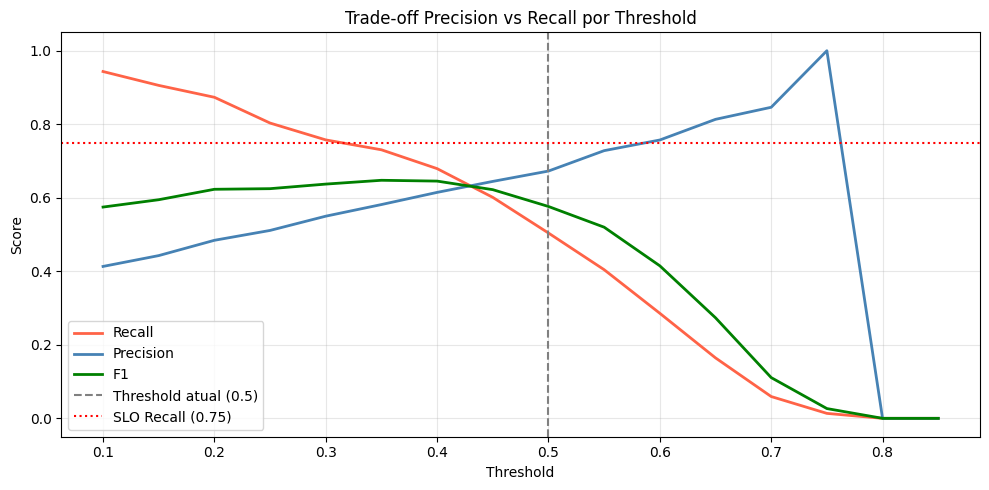


Melhor threshold para F1:    0.35
  Recall:    0.7305
  Precision: 0.5815
  F1:        0.6476

Threshold para Recall >= 0.75: 0.10
  Recall:    0.9434
  Precision: 0.4132
  F1:        0.5747


In [5]:
import numpy as np
from sklearn.metrics import f1_score, recall_score, precision_score
import matplotlib.pyplot as plt

# Testar diferentes thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
recalls, precisions, f1s = [], [], []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    recalls.append(recall_score(y_val, preds))
    precisions.append(precision_score(y_val, preds))
    f1s.append(f1_score(y_val, preds))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, recalls,    label="Recall",    color="tomato",    lw=2)
ax.plot(thresholds, precisions, label="Precision", color="steelblue", lw=2)
ax.plot(thresholds, f1s,        label="F1",        color="green",     lw=2)
ax.axvline(x=0.5, color="gray", linestyle="--", label="Threshold atual (0.5)")
ax.axhline(y=0.75, color="red", linestyle=":", label="SLO Recall (0.75)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Trade-off Precision vs Recall por Threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Maximizar F1
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]
print(f"\nMelhor threshold para F1:    {best_threshold:.2f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  F1:        {f1s[best_idx]:.4f}")

# threshold com Recall >= 0.75
recall_75_idx = next(i for i, r in enumerate(recalls) if r >= 0.75)
recall_75_threshold = thresholds[recall_75_idx]
print(f"\nThreshold para Recall >= 0.75: {recall_75_threshold:.2f}")
print(f"  Recall:    {recalls[recall_75_idx]:.4f}")
print(f"  Precision: {precisions[recall_75_idx]:.4f}")
print(f"  F1:        {f1s[recall_75_idx]:.4f}")

In [7]:
# Hiperparâmetros v2
HIDDEN_DIMS_V2   = [128, 64, 32]
DROPOUT_RATE_V2  = 0.4
LEARNING_RATE_V2 = 5e-4
BATCH_SIZE_V2    = 64
MAX_EPOCHS_V2    = 150
PATIENCE_V2      = 15

import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train,
)
pos_weight = torch.tensor([class_weights[1] / class_weights[0]])
print(f"Class weight positivo: {pos_weight.item():.4f}")

with mlflow.start_run(run_name="ChurnMLP_v2"):

    mlflow.log_params({
        "hidden_dims":   str(HIDDEN_DIMS_V2),
        "dropout_rate":  DROPOUT_RATE_V2,
        "learning_rate": LEARNING_RATE_V2,
        "batch_size":    BATCH_SIZE_V2,
        "max_epochs":    MAX_EPOCHS_V2,
        "patience":      PATIENCE_V2,
        "seed":          SEED,
        "input_dim":     X_train.shape[1],
        "class_weighted": True,
        "loss": "BCEWithLogitsLoss",
    })

    model_v2, history_v2 = train_model(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        input_dim=X_train.shape[1],
        hidden_dims=HIDDEN_DIMS_V2,
        dropout_rate=DROPOUT_RATE_V2,
        learning_rate=LEARNING_RATE_V2,
        batch_size=BATCH_SIZE_V2,
        max_epochs=MAX_EPOCHS_V2,
        patience=PATIENCE_V2,
    )

    device = get_device()
    y_proba_v2, _ = get_predictions(model_v2, X_val, device, threshold=0.5)

    THRESHOLD_V2 = float(recall_75_threshold)
    y_pred_v2 = (y_proba_v2 >= THRESHOLD_V2).astype(int)

    metrics_v2 = compute_metrics(y_val, y_proba_v2, y_pred_v2)
    cost_v2    = compute_cost_analysis(y_val, y_pred_v2)

    mlflow.log_params({"threshold": THRESHOLD_V2})
    mlflow.log_metrics({
        "roc_auc":   metrics_v2["roc_auc"],
        "pr_auc":    metrics_v2["pr_auc"],
        "f1":        metrics_v2["f1"],
        "recall":    metrics_v2["recall"],
        "precision": metrics_v2["precision"],
        "savings":   cost_v2["savings"],
    })

    for epoch, (tl, vl) in enumerate(
        zip(history_v2["train_loss"], history_v2["val_loss"]), start=1
    ):
        mlflow.log_metrics({"train_loss": tl, "val_loss": vl}, step=epoch)

    mlflow.pytorch.log_model(model_v2, artifact_path="model")

    print(f"\n=== MLP v2 — threshold={THRESHOLD_V2:.2f} ===")
    print(f"ROC-AUC:  {metrics_v2['roc_auc']:.4f}")
    print(f"PR-AUC:   {metrics_v2['pr_auc']:.4f}")
    print(f"F1:       {metrics_v2['f1']:.4f}")
    print(f"Recall:   {metrics_v2['recall']:.4f}")
    print(f"Economia: R${cost_v2['savings']:,.0f}".replace(",", "."))

Class weight positivo: 2.7739


2026/04/26 22:53:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 22:53:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/26 22:53:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



=== MLP v2 — threshold=0.10 ===
ROC-AUC:  0.8509
PR-AUC:   0.6644
F1:       0.5698
Recall:   0.9407
Economia: R$149.250


In [8]:
print("\n=== Comparativo v1 vs v2 ===")
print(f"{'Métrica':<15} {'v1':>10} {'v2':>10} {'Δ':>10}")
print("-" * 45)

v1 = {"ROC-AUC": 0.8317, "PR-AUC": 0.6380, "F1": 0.5723, "Recall": 0.5027}
v2 = {
    "ROC-AUC": metrics_v2["roc_auc"],
    "PR-AUC":  metrics_v2["pr_auc"],
    "F1":      metrics_v2["f1"],
    "Recall":  metrics_v2["recall"],
}

for metric in v1:
    delta = v2[metric] - v1[metric]
    sinal = "+" if delta > 0 else ""
    print(f"{metric:<15} {v1[metric]:>10.4f} {v2[metric]:>10.4f} {sinal}{delta:>9.4f}")

print("-" * 45)
print(f"{'Economia':<15} {'R$89.250':>10} R${cost_v2['savings']:,.0f}".replace(",", "."))


=== Comparativo v1 vs v2 ===
Métrica                 v1         v2          Δ
---------------------------------------------
ROC-AUC             0.8317     0.8509 +   0.0192
PR-AUC              0.6380     0.6644 +   0.0264
F1                  0.5723     0.5698   -0.0025
Recall              0.5027     0.9407 +   0.4380
---------------------------------------------
Economia          R$89.250 R$149.250


In [ ]:
# uv run jupyter notebook notebooks/03_mlp.ipynb
# uv run mlflow ui --backend-store-uri sqlite:///models/mlflow.db
# http://localhost:5000